# Movie Recommendation System — Phase 1: Data Loading & EDA
**Dataset:** CiaoDVD (`movie-ratings.txt`)  
**Course:** CSIT 360 — Advanced Techniques in Data Science  
**Spring 2026**

## 1. Imports & Setup

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import os

# Consistent plot style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

# Create output folders if they don't exist
os.makedirs('../results/figures', exist_ok=True)
os.makedirs('../data/processed', exist_ok=True)

print('Setup complete.')

Setup complete.


## 2. Load the Dataset

The `movie-ratings.txt` file is **tab-separated** with columns:  
`userId, movieId, movie-categoryId, reviewId, movieRating, reviewDate`

In [38]:
# --- EDIT THIS PATH if your file is somewhere else ---
DATA_PATH = '../data/raw/movie-ratings.txt'

col_names = ['userId', 'movieId', 'categoryId', 'reviewId', 'rating', 'reviewDate']

df = pd.read_csv(
    DATA_PATH,
    sep=',',          
    header=None,
    names=col_names
)

print(f'Loaded {len(df):,} rows.')
df.head(10)

Loaded 72,665 rows.


,userId,movieId,categoryId,reviewId,rating,reviewDate
0,1,1,1,1,5,2000-07-12
1,2,1,1,2,5,2000-07-12
2,3,1,1,3,5,2000-07-12
3,4,1,1,4,4,2000-07-12
4,5,1,1,5,4,2000-07-12
5,6,1,1,6,5,2000-07-15
6,7,1,1,7,4,2000-07-25
7,8,1,1,8,4,2000-07-28
8,9,1,1,9,3,2000-08-03
9,10,1,1,10,4,2000-08-07


## 3. Basic Statistics

In [39]:
n_users   = df['userId'].nunique()
n_movies  = df['movieId'].nunique()
n_ratings = len(df)

# Sparsity: fraction of the user-movie matrix that is EMPTY
total_possible = n_users * n_movies
sparsity = 1 - (n_ratings / total_possible)

print('=' * 40)
print(f'  Number of users   : {n_users:,}')
print(f'  Number of movies  : {n_movies:,}')
print(f'  Number of ratings : {n_ratings:,}')
print(f'  Matrix size       : {n_users:,} x {n_movies:,} = {total_possible:,}')
print(f'  Sparsity          : {sparsity:.4%}')
print('=' * 40)

  Number of users   : 17,615
  Number of movies  : 16,121
  Number of ratings : 72,665
  Matrix size       : 17,615 x 16,121 = 283,971,415
  Sparsity          : 99.9744%


## 4. Data Quality Check

In [40]:
print('--- Missing values ---')
print(df.isnull().sum())

print(f'\n--- Duplicate rows ---')
n_dups = df.duplicated().sum()
print(f'  Duplicates found: {n_dups}')

print(f'\n--- Rating range ---')
print(f'  Min: {df["rating"].min()}  |  Max: {df["rating"].max()}')

# Drop duplicates if any
if n_dups > 0:
    df = df.drop_duplicates()
    print(f'  Dropped {n_dups} duplicate rows. Remaining: {len(df):,}')
else:
    print('  No duplicates — data is clean!')

--- Missing values ---
userId        0
movieId       0
categoryId    0
reviewId      0
rating        0
reviewDate    0
dtype: int64

--- Duplicate rows ---
  Duplicates found: 0

--- Rating range ---
  Min: 1  |  Max: 5
  No duplicates — data is clean!


## 5. Rating Distribution

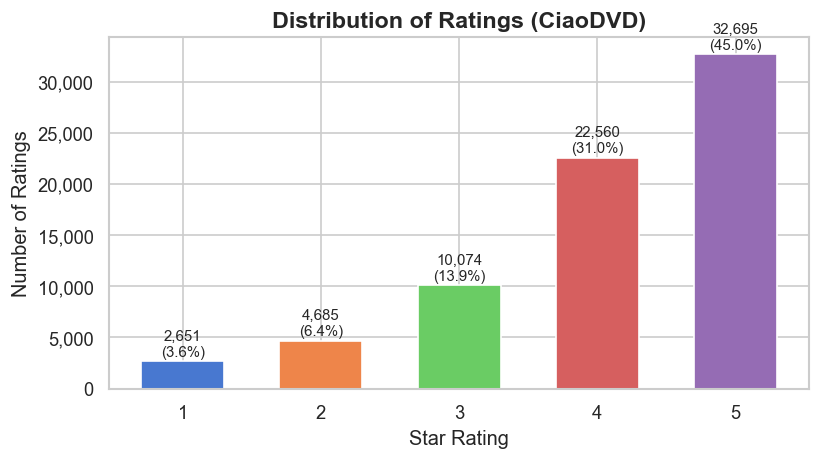

Saved → results/figures/rating_distribution.png


In [41]:
fig, ax = plt.subplots(figsize=(7, 4))

rating_counts = df['rating'].value_counts().sort_index()
bars = ax.bar(
    rating_counts.index,
    rating_counts.values,
    color=sns.color_palette('muted', 5),
    edgecolor='white',
    width=0.6
)

# Annotate each bar with count and percentage
total = rating_counts.sum()
for bar, count in zip(bars, rating_counts.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 200,
        f'{count:,}\n({count/total:.1%})',
        ha='center', va='bottom', fontsize=9
    )

ax.set_xlabel('Star Rating', fontsize=12)
ax.set_ylabel('Number of Ratings', fontsize=12)
ax.set_title('Distribution of Ratings (CiaoDVD)', fontsize=14, fontweight='bold')
ax.set_xticks([1, 2, 3, 4, 5])
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.tight_layout()
plt.savefig('../results/figures/rating_distribution.png', bbox_inches='tight')
plt.show()
print('Saved → results/figures/rating_distribution.png')

## 6. Long-Tail Distributions
### 6a. Ratings per User

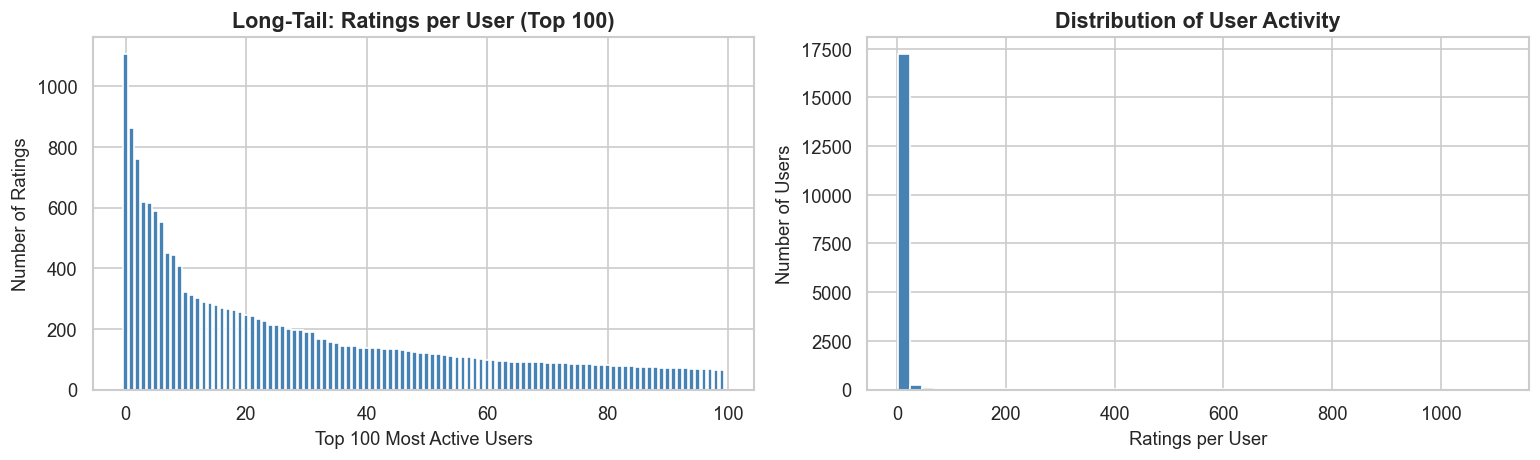

Median ratings per user : 1
Mean   ratings per user : 4.1
Max    ratings per user : 1106


In [46]:
ratings_per_user = df.groupby('userId')['rating'].count().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: show only top 100 users so bars are visible
top100 = ratings_per_user.head(100)
axes[0].bar(range(len(top100)), top100.values, color='steelblue', width=0.8)
axes[0].set_xlabel('Top 100 Most Active Users', fontsize=11)
axes[0].set_ylabel('Number of Ratings', fontsize=11)
axes[0].set_title('Long-Tail: Ratings per User (Top 100)', fontsize=13, fontweight='bold')

# Right: histogram (unchanged)
axes[1].hist(ratings_per_user.values, bins=50, color='steelblue', edgecolor='white')
axes[1].set_xlabel('Ratings per User', fontsize=11)
axes[1].set_ylabel('Number of Users', fontsize=11)
axes[1].set_title('Distribution of User Activity', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('../results/figures/ratings_per_user.png', bbox_inches='tight')
plt.show()

print(f'Median ratings per user : {ratings_per_user.median():.0f}')
print(f'Mean   ratings per user : {ratings_per_user.mean():.1f}')
print(f'Max    ratings per user : {ratings_per_user.max()}')

### 6b. Ratings per Movie

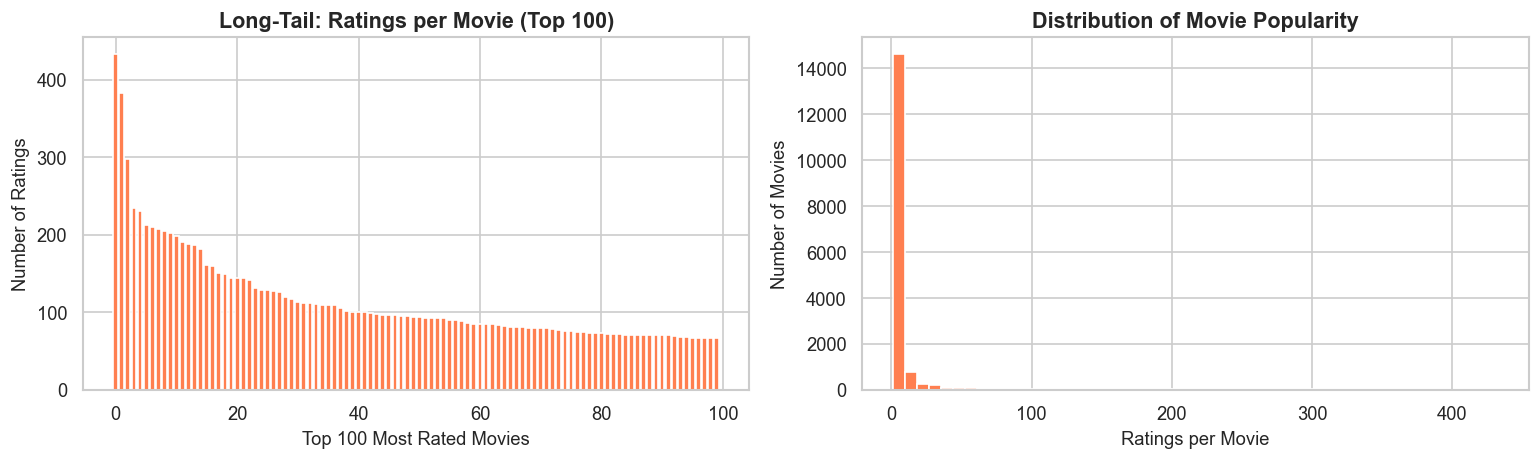

Median ratings per movie : 1
Mean   ratings per movie : 4.5
Max    ratings per movie : 433


In [43]:
ratings_per_movie = df.groupby('movieId')['rating'].count().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: top 100 movies only
top100_movies = ratings_per_movie.head(100)
axes[0].bar(range(len(top100_movies)), top100_movies.values, color='coral', width=0.8)
axes[0].set_xlabel('Top 100 Most Rated Movies', fontsize=11)
axes[0].set_ylabel('Number of Ratings', fontsize=11)
axes[0].set_title('Long-Tail: Ratings per Movie (Top 100)', fontsize=13, fontweight='bold')

# Right: histogram
axes[1].hist(ratings_per_movie.values, bins=50, color='coral', edgecolor='white')
axes[1].set_xlabel('Ratings per Movie', fontsize=11)
axes[1].set_ylabel('Number of Movies', fontsize=11)
axes[1].set_title('Distribution of Movie Popularity', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('../results/figures/ratings_per_movie.png', bbox_inches='tight')
plt.show()

print(f'Median ratings per movie : {ratings_per_movie.median():.0f}')
print(f'Mean   ratings per movie : {ratings_per_movie.mean():.1f}')
print(f'Max    ratings per movie : {ratings_per_movie.max()}')

## 7. Summary Statistics Table

In [44]:
summary = pd.DataFrame({
    'Metric': [
        'Total Ratings', 'Unique Users', 'Unique Movies',
        'Sparsity', 'Avg Rating', 'Median Ratings / User', 'Median Ratings / Movie'
    ],
    'Value': [
        f'{n_ratings:,}',
        f'{n_users:,}',
        f'{n_movies:,}',
        f'{sparsity:.4%}',
        f'{df["rating"].mean():.3f}',
        f'{ratings_per_user.median():.0f}',
        f'{ratings_per_movie.median():.0f}'
    ]
})

summary

,Metric,Value
0,Total Ratings,"72,665"
1,Unique Users,"17,615"
2,Unique Movies,"16,121"
3,Sparsity,99.9744%
4,Avg Rating,4.073
5,Median Ratings / User,1
6,Median Ratings / Movie,1


## 8. Save Cleaned Data

In [45]:
# Keep only the columns needed for modeling
df_clean = df[['userId', 'movieId', 'rating']].copy()
df_clean.to_csv('../data/processed/ratings_clean.csv', index=False)

print(f'Saved cleaned data: {len(df_clean):,} rows → data/processed/ratings_clean.csv')
df_clean.head()

Saved cleaned data: 72,665 rows → data/processed/ratings_clean.csv


,userId,movieId,rating
0,1,1,5
1,2,1,5
2,3,1,5
3,4,1,4
4,5,1,4
